In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

In [80]:
titanic = sns.load_dataset('titanic')

In [81]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [82]:
cols_to_keep = ['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']
df = titanic[cols_to_keep].copy()

In [83]:
df

,survived,pclass,sex,age,fare,embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S
...,...,...,...,...,...,...
886,0,2,male,27.0,13.0000,S
887,1,1,female,19.0,30.0000,S
888,0,3,female,NaN,23.4500,S
889,1,1,male,26.0,30.0000,C


In [84]:
df['age'] = df['age'].fillna(df['age'].median())

In [85]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [86]:
le_sex = LabelEncoder()
df['sex'] = le_sex.fit_transform(df['sex'])

In [87]:
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

In [88]:
X = df.drop('survived', axis=1)
y = df['survived']

In [89]:
X

,pclass,sex,age,fare,embarked_Q,embarked_S
0,3,1,22.0,7.2500,False,True
1,1,0,38.0,71.2833,False,False
2,3,0,26.0,7.9250,False,True
3,1,0,35.0,53.1000,False,True
4,3,1,35.0,8.0500,False,True
...,...,...,...,...,...,...
886,2,1,27.0,13.0000,False,True
887,1,0,19.0,30.0000,False,True
888,3,0,28.0,23.4500,False,True
889,1,1,26.0,30.0000,False,False


In [90]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: survived, Length: 891, dtype: int64

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [92]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
dec_tree = DecisionTreeClassifier(random_state=42)
rand_forest = RandomForestClassifier(n_estimators=100, random_state=42)

In [93]:
log_reg.fit(X_train, y_train)
dec_tree.fit(X_train, y_train)
rand_forest.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [94]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"--- {model_name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}\n")

print("MODEL EVALUATION RESULTS:\n")
evaluate_model(log_reg, X_test, y_test, "Logistic Regression")
evaluate_model(dec_tree, X_test, y_test, "Decision Tree")
evaluate_model(rand_forest, X_test, y_test, "Random Forest")

MODEL EVALUATION RESULTS:

--- Logistic Regression ---
Accuracy:  0.7989
Precision: 0.7639
Recall:    0.7432
ROC-AUC:   0.8799

--- Decision Tree ---
Accuracy:  0.7654
Precision: 0.7105
Recall:    0.7297
ROC-AUC:   0.7784

--- Random Forest ---
Accuracy:  0.7933
Precision: 0.7534
Recall:    0.7432
ROC-AUC:   0.8873



In [95]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rand_forest.feature_importances_
}).sort_values(by='Importance', ascending=False)

In [96]:
print("--- Feature Importances (Random Forest) ---")
print(feature_importances.to_string(index=False))

--- Feature Importances (Random Forest) ---
   Feature  Importance
      fare    0.324185
       age    0.280533
       sex    0.270811
    pclass    0.089907
embarked_S    0.023316
embarked_Q    0.011248


C:\Users\lenovo\AppData\Local\Temp\ipykernel_20044\1954838483.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')


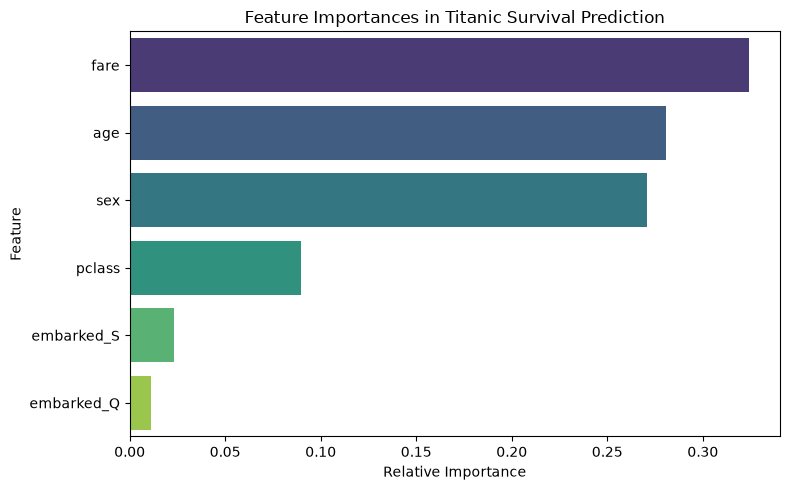

In [97]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title('Feature Importances in Titanic Survival Prediction')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [98]:
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
titanic['is_alone'] = (titanic['family_size'] == 1).astype(int)
titanic[['sibsp', 'parch', 'family_size', 'is_alone']].head(10)

,sibsp,parch,family_size,is_alone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1
5,0,0,1,1
6,0,0,1,1
7,3,1,5,0
8,0,2,3,0
9,1,0,2,0


In [99]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}


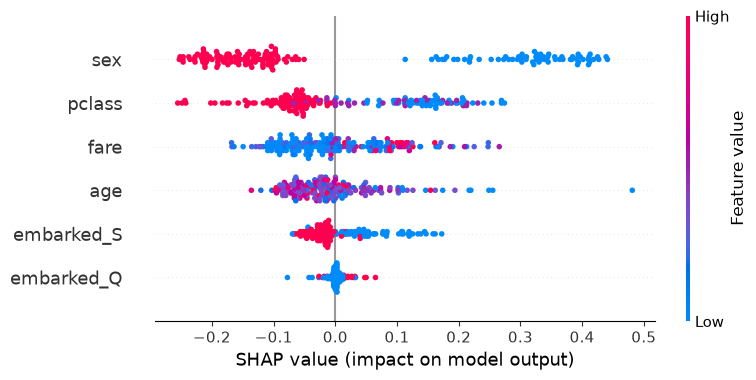

In [100]:
import shap
explainer = shap.TreeExplainer(rand_forest)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values[:, :, 1], X_test)

In [101]:
final_results = X_test.copy()
final_results['Actual_Survived'] = y_test
y_pred = rand_forest.predict(X_test)
final_results['Predicted_Survived'] = y_pred
final_results.to_csv('titanic_predictions.csv', index=False)

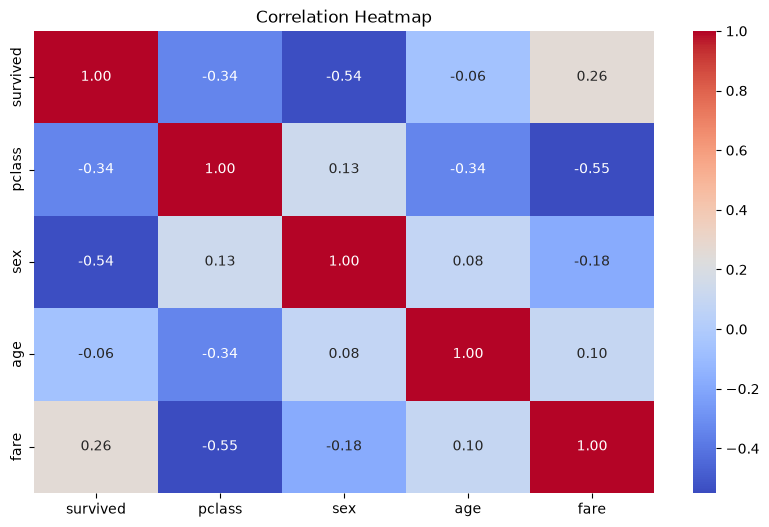

In [102]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

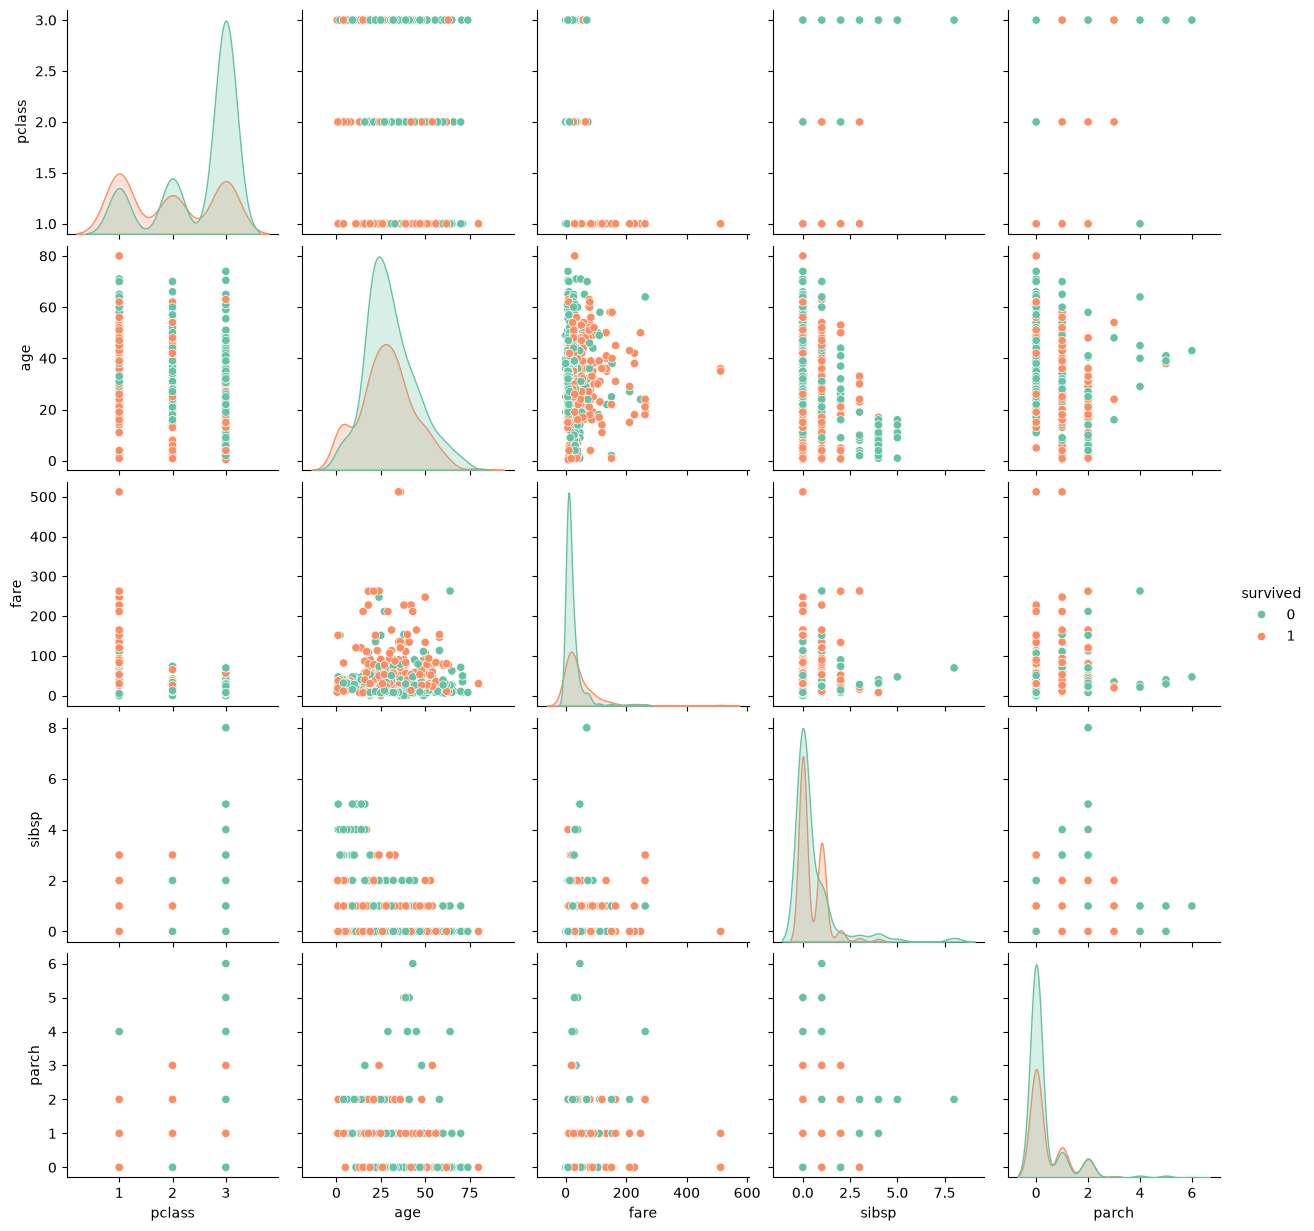

In [103]:
sns.pairplot(titanic[['survived', 'pclass', 'age', 'fare', 'sibsp', 'parch']],
             hue='survived',
             palette='Set2')

plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_20044\2182240629.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='survived',


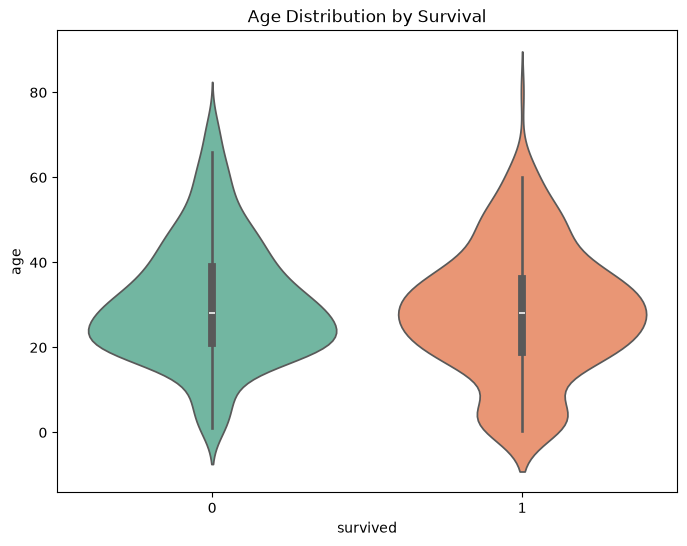

In [104]:
plt.figure(figsize=(8,6))

sns.violinplot(x='survived',
               y='age',
               data=titanic,
               palette='Set2')

plt.title("Age Distribution by Survival")
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_20044\1393717954.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pclass',


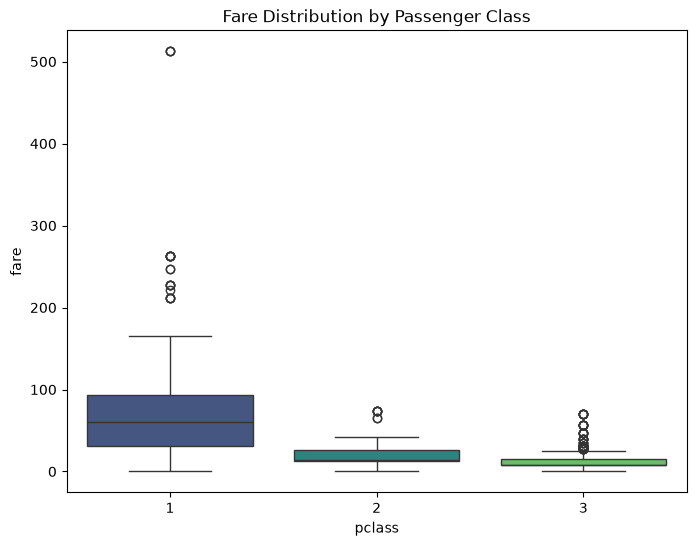

In [105]:
plt.figure(figsize=(8,6))

sns.boxplot(x='pclass',
            y='fare',
            data=titanic,
            palette='viridis')

plt.title("Fare Distribution by Passenger Class")
plt.show()

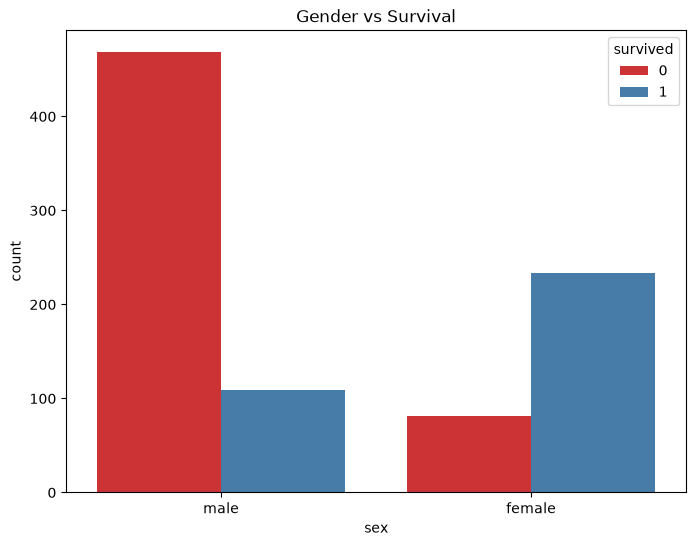

In [106]:
plt.figure(figsize=(8,6))

sns.countplot(x='sex',
              hue='survived',
              data=titanic,
              palette='Set1')

plt.title("Gender vs Survival")
plt.show()

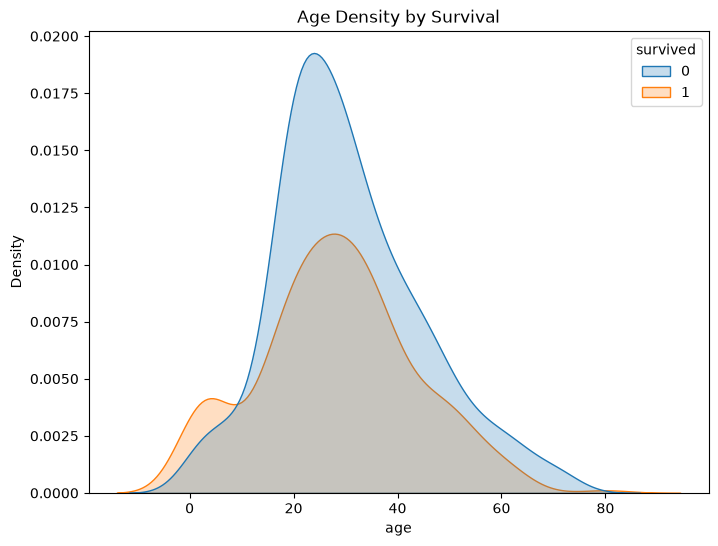

In [107]:
plt.figure(figsize=(8,6))

sns.kdeplot(data=titanic,
            x='age',
            hue='survived',
            fill=True)

plt.title("Age Density by Survival")
plt.show()

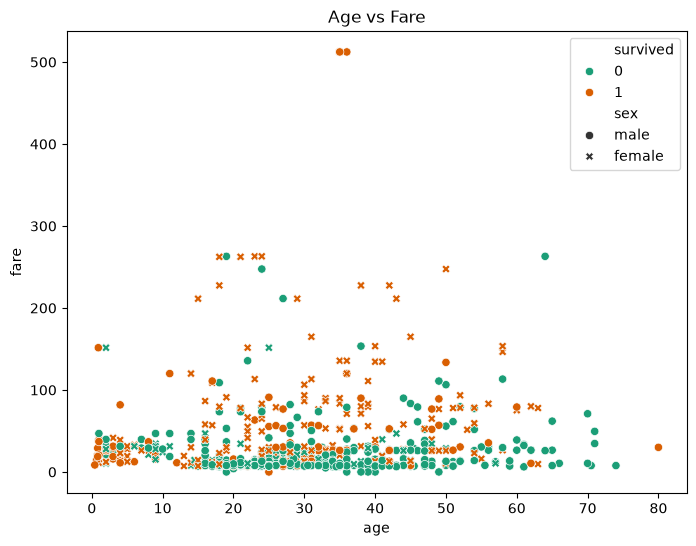

In [108]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=titanic,
                x='age',
                y='fare',
                hue='survived',
                style='sex',
                palette='Dark2')

plt.title("Age vs Fare")
plt.show()

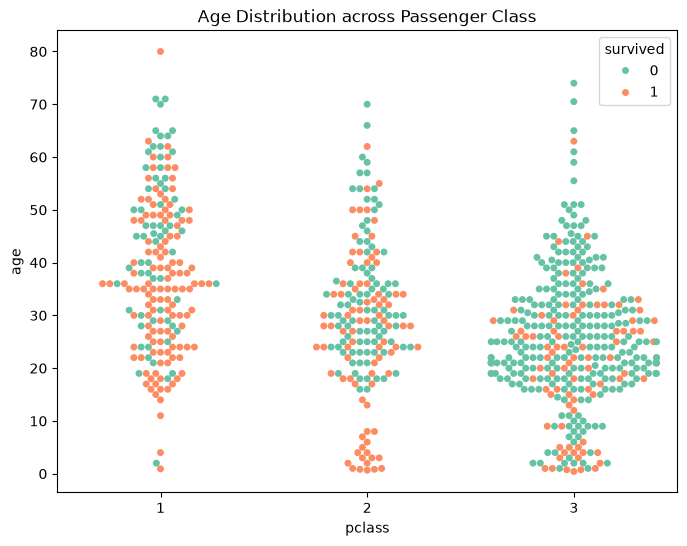

In [109]:
plt.figure(figsize=(8,6))

sns.swarmplot(data=titanic,
              x='pclass',
              y='age',
              hue='survived',
              palette='Set2')

plt.title("Age Distribution across Passenger Class")
plt.show()

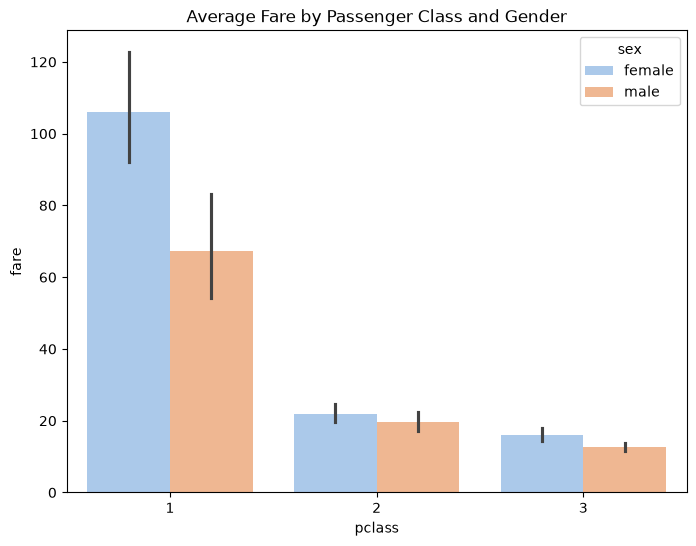

In [110]:
plt.figure(figsize=(8,6))

sns.barplot(data=titanic,
            x='pclass',
            y='fare',
            hue='sex',
            palette='pastel')

plt.title("Average Fare by Passenger Class and Gender")
plt.show()

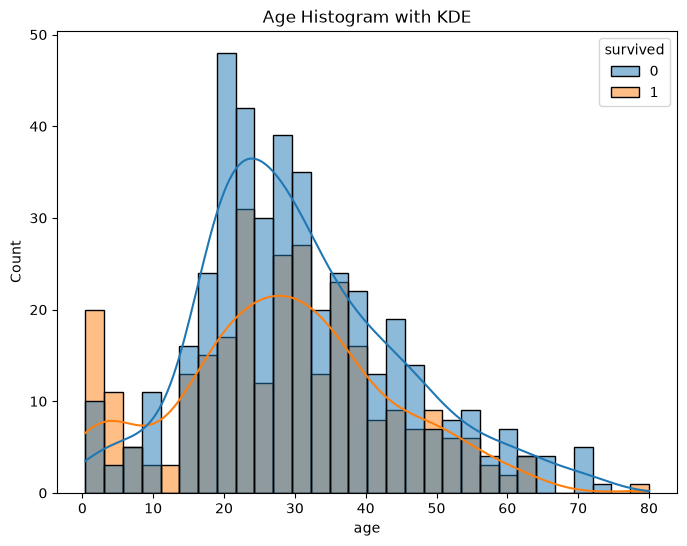

In [111]:
plt.figure(figsize=(8,6))

sns.histplot(data=titanic,
             x='age',
             hue='survived',
             kde=True,
             bins=30)

plt.title("Age Histogram with KDE")
plt.show()

In [112]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size,is_alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,1,1
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,1,1
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,4,0
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,1,1


In [113]:
features = ['pclass', 'sex', 'age', 'fare', 'sibsp', 'parch', 'embarked']
target = 'survived'

X = titanic[features]
y = titanic[target]

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['sex', 'embarked', 'pclass']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [115]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

numeric_features = ['age', 'fare', 'sibsp', 'parch']
# ensure numeric feature name matches dataframe and rebuild preprocessor before fitting
numeric_features = ['age', 'fare', 'sibsp', 'parch']

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pclass','sex','age',...,'sibsp','parch','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining colum

In [116]:
from sklearn.metrics import accuracy_score, classification_report

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, ['age', 'fare', 'sibsp', 'parch']),
    ('cat', categorical_transformer, categorical_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.8156424581005587
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       105
           1       0.78      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [117]:
import pandas as pd

new_passenger = pd.DataFrame({
    'pclass':[1],
    'sex':['female'],
    'age':[30],
    'fare':[80],
    'sibsp':[0],
    'parch':[0],
    'embarked':['S']
})

prediction = model.predict(new_passenger)

print("Predicted Survival:", prediction[0])

Predicted Survival: 1


In [118]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train_processed,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

loss, accuracy = model.evaluate(X_test_processed, y_test)

print("Accuracy:", accuracy)

c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.4569 - loss: 0.7028 - val_accuracy: 0.7413 - val_loss: 0.6550
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7592 - loss: 0.6328 - val_accuracy: 0.7902 - val_loss: 0.6035
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7961 - loss: 0.5846 - val_accuracy: 0.7972 - val_loss: 0.5508
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7961 - loss: 0.5346 - val_accuracy: 0.8322 - val_loss: 0.4905
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7996 - loss: 0.4922 - val_accuracy: 0.8392 - val_loss: 0.4443
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7996 - loss: 0.4619 - val_accuracy: 0.8322 - val_loss: 0.4263
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8049 - loss: 0.4470 - val_accuracy: 0.8322 - val_loss: 0.4093
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8084 - loss: 0.4346 - val_accuracy: 0.8252 - v

In [119]:
features = [
    'pclass',
    'sex',
    'age',
    'fare',
    'sibsp',
    'parch',
    'embarked'
]

target = 'survived'

X = titanic[features]
y = titanic[target]

In [120]:
numeric_features = ['age','fare','sibsp','parch']
categorical_features = ['sex','embarked','pclass']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [121]:
lr = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.7988826815642458


In [122]:
rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8156424581005587


In [123]:
from xgboost import XGBClassifier
xgb = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric='logloss'
    ))
])

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.8212290502793296


In [124]:
X_train_nn = preprocessor.fit_transform(X_train)
X_test_nn = preprocessor.transform(X_test)

input_dim = X_train_nn.shape[1]

nn = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn.fit(
    X_train_nn,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss, nn_acc = nn.evaluate(X_test_nn, y_test, verbose=0)

print("Neural Network Accuracy:", nn_acc)

c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network Accuracy: 0.826815664768219


In [125]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Neural Network"
    ],
    "Accuracy":[
        lr_acc,
        rf_acc,
        xgb_acc,
        nn_acc
    ]
})

results = results.sort_values("Accuracy", ascending=False)

print(results)

                 Model  Accuracy
3       Neural Network  0.826816
2              XGBoost  0.821229
1        Random Forest  0.815642
0  Logistic Regression  0.798883


C:\Users\lenovo\AppData\Local\Temp\ipykernel_20044\474378358.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


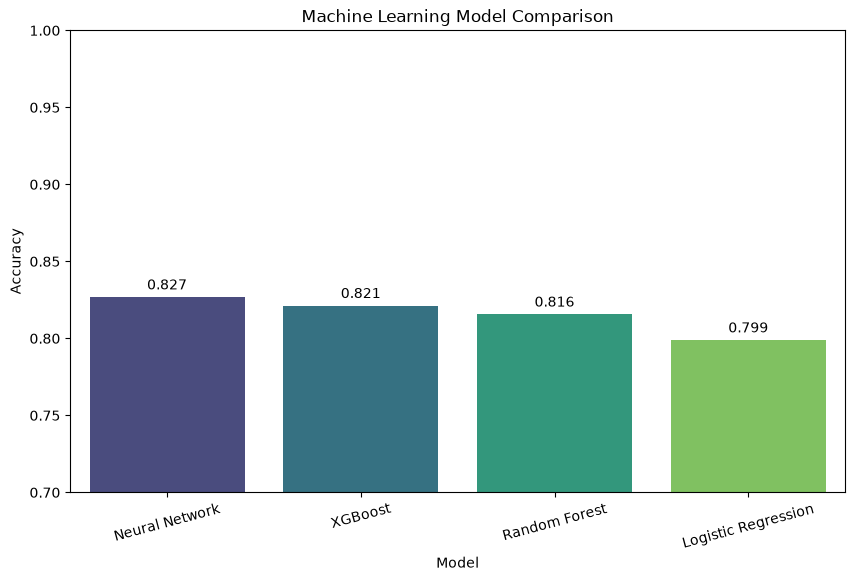

In [126]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title("Machine Learning Model Comparison")
plt.xticks(rotation=15)
plt.ylim(0.7,1.0)

for index, value in enumerate(results["Accuracy"]):
    plt.text(index, value+0.005, f"{value:.3f}", ha='center')

plt.show()

In [127]:
from sklearn.model_selection import GridSearchCV

lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(
    lr_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best CV Accuracy:", grid_lr.best_score_)

best_lr = grid_lr.best_estimator_

Best Parameters: {'model__C': 0.1, 'model__solver': 'liblinear'}
Best CV Accuracy: 0.8019304639022948


In [128]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 5, 10, 15, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__bootstrap': [True, False]
}

random_rf = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_rf.fit(X_train, y_train)

print("Best Parameters:", random_rf.best_params_)
print("Best CV Accuracy:", random_rf.best_score_)

best_rf = random_rf.best_estimator_

Best Parameters: {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': 5, 'model__bootstrap': False}
Best CV Accuracy: 0.821609376538954


In [129]:
xgb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 4, 5, 6],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

random_xgb = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_xgb.fit(X_train, y_train)

print("Best Parameters:", random_xgb.best_params_)
print("Best CV Accuracy:", random_xgb.best_score_)

best_xgb = random_xgb.best_estimator_

Best Parameters: {'model__subsample': 1.0, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}
Best CV Accuracy: 0.8412784398699891


In [130]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

results = []

for name, model in models.items():
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results.append({
        "Model": name,
        "Accuracy": acc
    })

results = pd.DataFrame(results)
results.sort_values("Accuracy", ascending=False)

,Model,Accuracy
1,Random Forest,0.815642
2,XGBoost,0.815642
0,Logistic Regression,0.798883


C:\Users\lenovo\AppData\Local\Temp\ipykernel_20044\3048649852.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


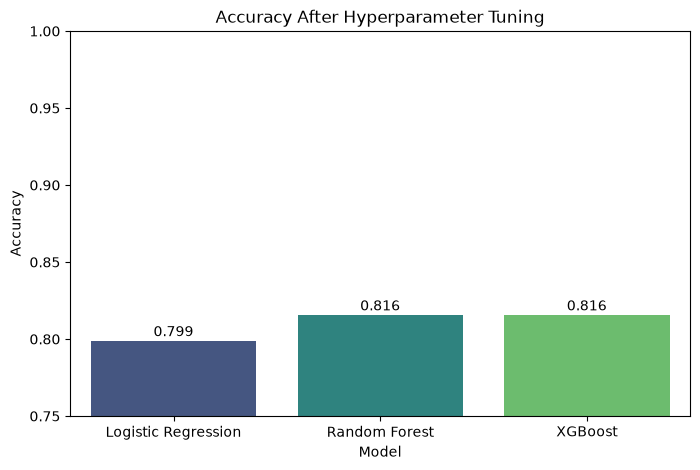

In [131]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy',
    palette='viridis'
)

plt.ylim(0.75,1.0)
plt.title("Accuracy After Hyperparameter Tuning")

for i, acc in enumerate(results["Accuracy"]):
    plt.text(i, acc+0.003, f"{acc:.3f}", ha='center')

plt.show()